In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [2]:

CLASS_MAP = {
    "A": 1,
    "B": 1,
    "F": 1,
    "L": 1,
    "N": 0,
    "R": 1,
    "V": 1,
    "f": 1
}

In [3]:
def list_csv_files(root_dir):
    files = []
    for root, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.endswith(".csv"):
                files.append(os.path.join(root, f))
    return files


In [4]:
class ECGDataset(Dataset):
    def __init__(self, files, class_map, max_len=600):
        self.files = files
        self.class_map = class_map
        self.max_len = max_len
        self.labels = []

        for f in self.files:
            cls = os.path.basename(os.path.dirname(f))
            self.labels.append(self.class_map[cls])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        signal = pd.read_csv(self.files[idx]).iloc[:, 0].values
        signal = signal.astype(np.float32)

        # Padding / corte (ESSENCIAL)
        if len(signal) < self.max_len:
            signal = np.pad(signal, (0, self.max_len - len(signal)))
        else:
            signal = signal[:self.max_len]

        signal = torch.tensor(signal).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return signal, label


In [5]:
class ECGCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Linear(64, 1)

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        return self.classifier(x)


In [15]:
class ECGCNN_Melhorado(nn.Module):
    def __init__(self):
        super().__init__()
        # Bloco de extração de características (Convoluções)
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Garante que a saída tenha tamanho 1 no eixo temporal
        )
        
        # Bloco de classificação (Camadas lineares)
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # 1. Passa o sinal pelas camadas de convolução
        # x esperado: [batch_size, 1, 600]
        x = self.features(x) 
        
        # 2. Achata o tensor (Flatten)
        # Após o AdaptiveAvgPool1d, o shape é [batch_size, 64, 1]
        # Precisamos converter para [batch_size, 64] para a camada Linear
        x = x.view(x.size(0), -1) 
        
        # 3. Passa pelo classificador final
        x = self.classifier(x)
        
        return x

In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x).squeeze()
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x).squeeze()
                loss = criterion(logits, y)
                val_loss += loss.item()

                preds = (torch.sigmoid(logits) > 0.5).int()
                correct += (preds == y.int()).sum().item()
                total += y.size(0)

        val_losses.append(val_loss / len(val_loader))
        acc = correct / total

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | "
              f"Val Acc: {acc:.4f}")

    return train_losses, val_losses


In [22]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model_optimized(model, train_loader, val_loader, criterion, optimizer, device, epochs=50):
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    early_stopping = EarlyStopping(patience=7, verbose=True, path='best_model.pt')
    
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        train_loss = running_loss / len(train_loader.dataset)
        
        # Validação
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                preds = (torch.sigmoid(outputs) > 0.5).float()
                correct += (preds == labels).sum().item()
        
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        # Atualiza o Scheduler e o Early Stopping
        scheduler.step(val_loss)
        early_stopping(val_loss, model)
        
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break
            
    # Carregar o melhor modelo guardado
    model.load_state_dict(torch.load('best_model.pt'))
    return train_losses, val_losses

In [8]:
def evaluate_with_confusion_matrix(model, dataloader, device, threshold=0.5):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x).squeeze()
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).long()

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    print("Classification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Arritmia"]
    ))

    return cm


In [9]:
def plot_confusion_matrix(cm):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Arritmia"],
        yticklabels=["Normal", "Arritmia"]
    )
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")
    plt.tight_layout()
    plt.show()


In [24]:
class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

Device: cuda
Total de arquivos no treino: 39235
Total de arquivos na validação: 8443
Epoch 1/50 | Train Loss: 0.1299 | Val Loss: 0.0910 | Val Acc: 0.8820
Validation loss decreased (inf --> 0.090987). Saving model...
Epoch 2/50 | Train Loss: 0.0674 | Val Loss: 0.0576 | Val Acc: 0.9614
Validation loss decreased (0.090987 --> 0.057572). Saving model...
Epoch 3/50 | Train Loss: 0.0534 | Val Loss: 0.0462 | Val Acc: 0.9608
Validation loss decreased (0.057572 --> 0.046181). Saving model...
Epoch 4/50 | Train Loss: 0.0459 | Val Loss: 0.0397 | Val Acc: 0.9717
Validation loss decreased (0.046181 --> 0.039651). Saving model...
Epoch 5/50 | Train Loss: 0.0425 | Val Loss: 0.0415 | Val Acc: 0.9807
EarlyStopping counter: 1 out of 7
Epoch 6/50 | Train Loss: 0.0378 | Val Loss: 0.0531 | Val Acc: 0.9636
EarlyStopping counter: 2 out of 7
Epoch 7/50 | Train Loss: 0.0389 | Val Loss: 0.0402 | Val Acc: 0.9530
EarlyStopping counter: 3 out of 7
Epoch 8/50 | Train Loss: 0.0359 | Val Loss: 0.0394 | Val Acc: 0.979

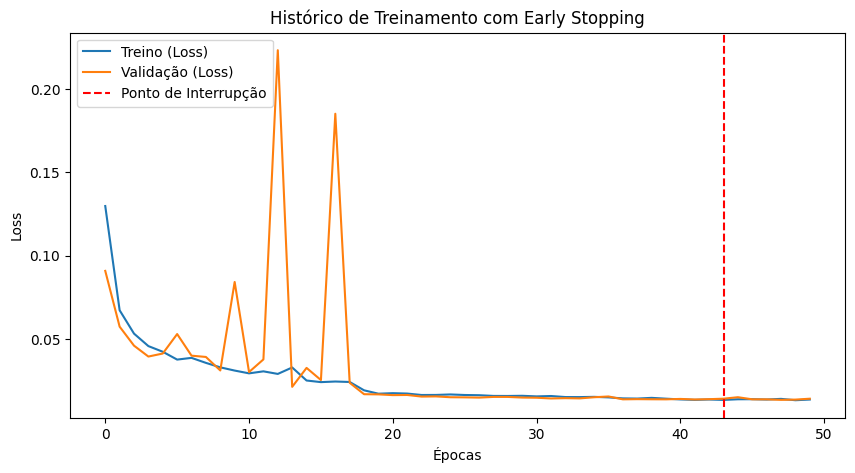

In [32]:
if __name__ == "__main__":


    CLASS_MAP = {
        "A": 1,
        "B": 1,
        "F": 1,
        "L": 1,
        "N": 0,
        "R": 1,
        "V": 1,
        "f": 1
    }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_files = list_csv_files("dataset_split_2/train")
    val_files   = list_csv_files("dataset_split_2/val")

    print(f"Total de arquivos no treino: {len(train_dataset)}")
    print(f"Total de arquivos na validação: {len(val_dataset)}")
    train_dataset = ECGDataset(train_files, CLASS_MAP)
    val_dataset   = ECGDataset(val_files, CLASS_MAP)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

    model = ECGCNN_Melhorado().to(device)

    # Class weight (opcional, mas recomendado)
    num_pos = sum(train_dataset.labels)
    num_neg = len(train_dataset.labels) - num_pos
    pos_weight = torch.tensor([num_neg / num_pos]).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 4. CHAMADA DA NOVA FUNÇÃO
    # Note que agora passamos 50 épocas, mas o Early Stopping deve parar antes
    train_losses, val_losses = train_model_optimized(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=50
    )

# 5. Plotar os resultados para ver onde o Early Stopping parou
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Treino (Loss)")
    plt.plot(val_losses, label="Validação (Loss)")
    plt.axvline(x=len(train_losses)-7, color='r', linestyle='--', label='Ponto de Interrupção')
    plt.legend()
    plt.title("Histórico de Treinamento com Early Stopping")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.show()


Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97      1499
    Arritmia       1.00      0.99      0.99      6944

    accuracy                           0.99      8443
   macro avg       0.97      0.99      0.98      8443
weighted avg       0.99      0.99      0.99      8443



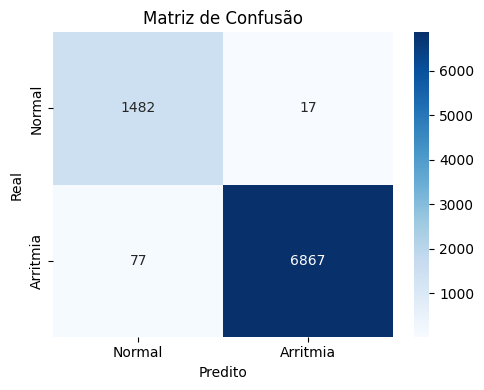

In [33]:
cm = evaluate_with_confusion_matrix(
    model,
    val_loader,
    device,
    threshold=0.5
)

plot_confusion_matrix(cm)
